In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
from recovar.config import BATCH_SIZE
from recovar.representation_learning_models import (
    RepresentationLearningSingleAutoencoder,
    RepresentationLearningDenoisingSingleAutoencoder,
    RepresentationLearningMultipleAutoencoder
)
from recovar.classifier_models import (
    ClassifierAutocovariance, 
    ClassifierAugmentedAutoencoder, 
    ClassifierMultipleAutoencoder
)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

2025-11-21 17:41:04.111154: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 17:41:04.146615: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-21 17:41:04.146651: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-21 17:41:04.146672: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-21 17:41:04.153883: I tensorflow/core/platform/cpu_feature_g

In [2]:
# ============================
# 1. Configuration
# ============================

# Paths to your data
TEST_DATA_PATH = 'data/X_test_1280sample.npy'  # Replace with your actual path
TEST_LABEL_PATH = 'data/Y_test_1280sample.npy'  # Replace with your actual path

# Paths to your model
MODEL_PATH = '/mnt/data_a/ege/recovar_models/slvt_picked_batch_match/representation_learning_autoencoder_ensemble/SLVT_fixed/split0/ep4.h5'

In [3]:
# ============================
# 2. Data loading
# ============================
X_test = np.load(TEST_DATA_PATH)
print(f"Test data shape: {X_test.shape}")

Y_test = np.load(TEST_LABEL_PATH)  # Expected shape: (num_samples)
print(f"Test label shape: {Y_test.shape}")

Test data shape: (1280, 3000, 3)
Test label shape: (1280,)


In [4]:
# ============================
# 3. Representation Learning Model Instantiation
# ============================

# Choose the model you want to train
# For example, using RepresentationLearningSingleAutoencoder
#model = RepresentationLearningSingleAutoencoder(
#    name="rep_learning_autoencoder"
#)

# Alternatively, you can choose other models:
# model = RepresentationLearningDenoisingSingleAutoencoder(
#     name="rep_learning_denoising_autoencoder",
#     input_noise_std=1e-6,
#     denoising_noise_std=2e-1
# )
model = RepresentationLearningMultipleAutoencoder(
     name="rep_learning_autoencoder_ensemble",
     input_noise_std=1e-6,
     eps=1e-27
)

2025-11-21 17:41:07.236392: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-11-21 17:41:07.236440: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: boxx-server
2025-11-21 17:41:07.236447: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: boxx-server
2025-11-21 17:41:07.236531: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 470.256.2
2025-11-21 17:41:07.236551: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 470.256.2
2025-11-21 17:41:07.236555: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:309] kernel version seems to match DSO: 470.256.2


In [5]:
# ============================
# 4. Model Compilation
# ============================
model.compile()
model(X_test)
model.load_weights(MODEL_PATH)

Mi_single and Mi_single Oversamples tf.Tensor(
[[3.0695724 4.363176  3.260654  ... 3.3220081 2.8326821 4.170011 ]
 [2.9700067 2.8639278 3.3105645 ... 2.8195927 2.803615  2.8118186]
 [2.8023367 2.851531  2.844007  ... 4.369224  3.8937488 4.1208   ]
 ...
 [3.090938  3.3695972 2.921596  ... 2.7852583 2.8071544 2.841728 ]
 [2.8406906 2.903344  2.8155596 ... 2.8844786 3.583478  2.8770723]
 [2.8436625 2.8609414 2.8159084 ... 2.8049433 2.8078442 2.7882397]], shape=(1280, 1500), dtype=float32) tf.Tensor(
[[4583.057  4562.996  1797.739  ...    0.        0.        0.    ]
 [4490.794  4380.6562 1698.0736 ...    0.        0.        0.    ]
 [4640.9214 4632.3877 1841.1082 ...    0.        0.        0.    ]
 ...
 [4437.883  4435.7744 1756.6764 ...    0.        0.        0.    ]
 [4152.841  4114.9487 1624.951  ...    0.        0.        0.    ]
 [4709.4297 4671.744  1834.775  ...    0.        0.        0.    ]], shape=(1280, 3000), dtype=float32)
Mi_single and Mi_single Oversamples tf.Tensor(
[[1.340

In [6]:
results_picks = model(X_test,training=False)

Mi_single and Mi_single Oversamples tf.Tensor(
[[1.0123316  1.2142231  0.62722266 ... 0.33952665 1.0876663  1.2028345 ]
 [0.76240325 1.2775716  0.83111674 ... 0.70864654 0.8303059  0.7999666 ]
 [0.66539466 1.2291527  0.651266   ... 0.6778061  0.7097218  0.47649825]
 ...
 [0.92520297 0.8324156  0.51686406 ... 0.9580725  0.65143716 0.6878802 ]
 [0.5452119  0.77035713 0.6555491  ... 0.63572955 0.5431731  0.7193168 ]
 [0.61566377 0.75690234 0.68962896 ... 0.98928237 0.9719751  0.8417984 ]], shape=(1280, 1500), dtype=float32) tf.Tensor(
[[-2.0802368e+03 -1.9663843e+03 -6.5141504e+02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-1.7369014e+04 -1.3616618e+04 -3.8774326e+03 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-4.1397563e+03 -3.1824424e+03 -8.4168750e+02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [-5.9354858e+02 -3.9937860e+02 -5.1074692e+01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-2.7951262e+06 -2.0107278e+06 -5.3207581e+05 ...  0.0000000

In [7]:
f1p, f2p, f3p, f4p, f5p, y1, y2, y3, y4, y5, surprise, pick_index, pickability_score = results_picks
surprise = results_picks[-3]
pick_index = results_picks[-2]
pickability_score = results_picks[-1]


In [8]:
surprise, pick_index

(<tf.Tensor: shape=(1280, 2000), dtype=float32, numpy=
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>,
 <tf.Tensor: shape=(1280,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 0])>)

In [9]:
def plot_pick_simple(surprise, pick_index, idx=100):
    """Simple plot of surprise, pick, and score for one sample."""
    fig, ax = plt.subplots(figsize=(12, 4))

    # Get single sample data
    s = surprise[idx].numpy() if hasattr(surprise[idx], 'numpy') else surprise[idx]
    p_idx = int(pick_index[idx].numpy() if hasattr(pick_index[idx], 'numpy') else pick_index[idx])

    # Plot
    ax.plot(s, alpha=0.7)
    ax.axvline(p_idx, color='red', linestyle='--', label=f'Pick: {p_idx}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Surprise')
    ax.legend()
    ax.grid(alpha=0.3)

    return fig, ax

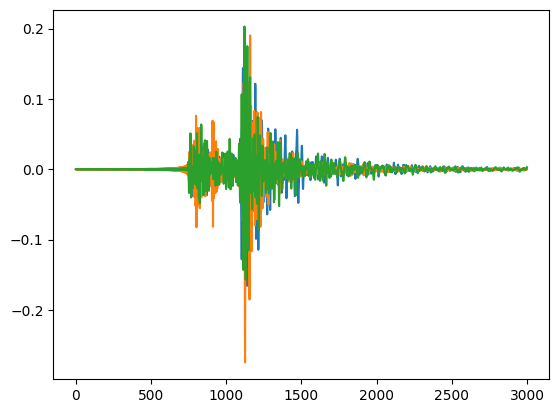

In [10]:
plt.plot(X_test[100])

(<Figure size 1200x400 with 1 Axes>, <Axes: xlabel='Time', ylabel='Surprise'>)

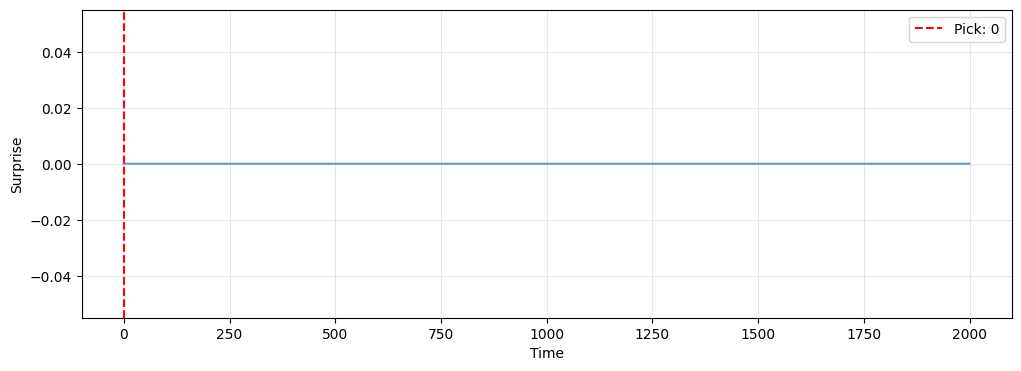

In [11]:
plot_pick_simple(surprise=surprise, pick_index=pick_index)

In [6]:
# ============================
# 5. Classifier Model Instantiation
# ============================

# Choose the model for classification. This is just for convenience, these models are actually wrappers around
#representation learning models.
# For example, using RepresentationLearningSingleAutoencoder
# model_classifier = ClassifierAutocovariance(model)

# Alternatively, you can choose other wrappers. 
# model_classifier = ClassifierAugmentedAutoencoder(model)
model_classifier = ClassifierMultipleAutoencoder(model)

"""Note: One should be careful about the compatibility of the classifier wrappers with the models. RepresentationLearningSingleAutoencoder and RepresentationLearningDenoising
Autoencoder are compatible with ClassifierAutocovariance, ClassifierAugmentedAutoencoder. However, RepresentationLearningMultipleAutoencoder is only compatible with 
ClassifierMultipleAutoencoder. """

'Note: One should be careful about the compatibility of the classifier wrappers with the models. RepresentationLearningSingleAutoencoder and RepresentationLearningDenoising\nAutoencoder are compatible with ClassifierAutocovariance, ClassifierAugmentedAutoencoder. However, RepresentationLearningMultipleAutoencoder is only compatible with \nClassifierMultipleAutoencoder. '

In [7]:
# ============================
# 6. Obtain earthquake probabilities
# ============================
earthquake_scores = model_classifier(X_test)

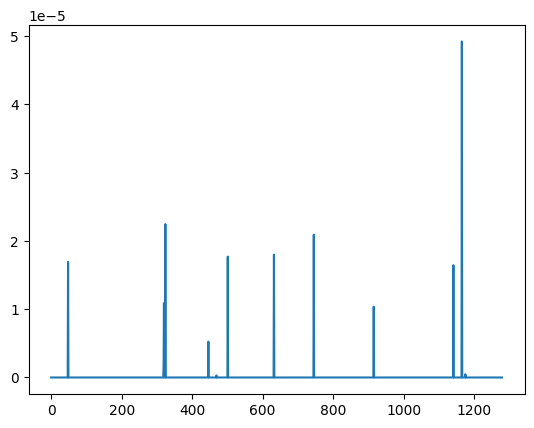

In [30]:
plt.plot(earthquake_scores)

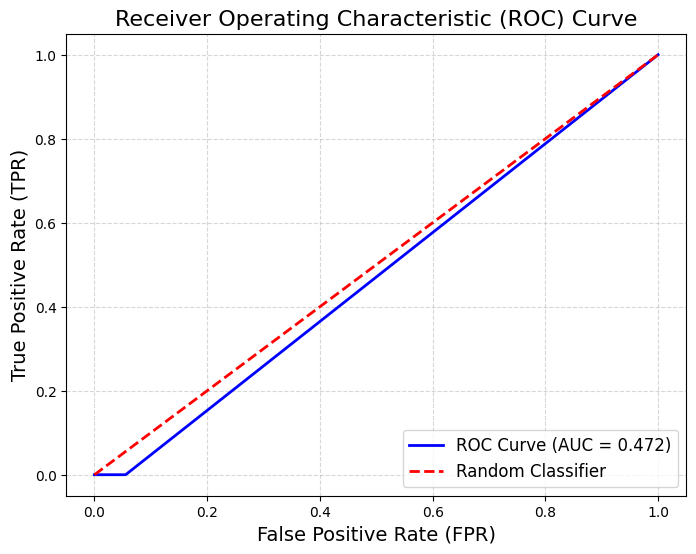

In [8]:
# ============================
# 7. Plot ROC curve.
# ============================
fpr, tpr, __ = roc_curve(Y_test, earthquake_scores)
auc_score = roc_auc_score(y_true=Y_test, y_score=earthquake_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()